<a href="https://colab.research.google.com/github/Wilson-G9/Lab5_Bai3_Giac_Ngu./blob/main/Bai3_Giac_Ngu_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Bài 3: Phân loại và Dự báo Chất lượng Giấc ngủ
**Dataset:** Sleep_health_and_lifestyle_dataset.csv | **374 mẫu, 13 cột**  
**Thuật toán:** K-Means (Sklearn & Custom cài đặt tay)

## 📦 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import ipywidgets as widgets
from IPython.display import display, clear_output

print("✅ Import thành công!")

✅ Import thành công!


## 📂 Bước 1: Tải dữ liệu

In [2]:
from google.colab import files
uploaded = files.upload()   # Upload Sleep_health_and_lifestyle_dataset.csv

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
print("Shape:", df.shape)
print("\nCác cột:", df.columns.tolist())
print()
df.head(10)

Saving Sleep_health_and_lifestyle_dataset.csv to Sleep_health_and_lifestyle_dataset.csv
Shape: (374, 13)

Các cột: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


## 🔍 Bước 2: Khám phá dữ liệu ban đầu

In [3]:
print("=== Thông tin tổng quan ===")
df.info()
print()
print("=== Thống kê mô tả ===")
df.describe()

=== Thông tin tổng quan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [4]:
print("=== Giá trị thiếu (Missing Values) ===")
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print("=== Giá trị duy nhất các cột phân loại ===")
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    print(f"  {col}: {df[col].unique()}")

=== Giá trị thiếu (Missing Values) ===
Sleep Disorder    219
dtype: int64

=== Giá trị duy nhất các cột phân loại ===
  Gender: ['Male' 'Female']
  Occupation: ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
  BMI Category: ['Overweight' 'Normal' 'Obese' 'Normal Weight']
  Sleep Disorder: [nan 'Sleep Apnea' 'Insomnia']


## ✂️ Bước 3: Xử lý – Bỏ các cột không cần thiết

Phân tích từng cột để quyết định giữ hay loại bỏ:

| Cột | Quyết định | Lý do |
|-----|-----------|-------|
| Person ID | ❌ **Bỏ** | Chỉ là mã định danh, không mang thông tin phân tích |
| Occupation | ❌ **Bỏ** | Có 11 giá trị, nhiều nhiễu, không trực tiếp ảnh hưởng giấc ngủ |
| Blood Pressure | ❌ **Bỏ** | Dạng chuỗi "120/80", cần xử lý phức tạp, nằm ngoài phạm vi bài |
| Sleep Disorder | ❌ **Bỏ** | 219/374 giá trị thiếu (~59%), không đủ tin cậy để dùng |
| Gender | ✅ **Giữ** | Encode → 0/1, có ảnh hưởng đến thói quen ngủ |
| Age | ✅ **Giữ** | Liên quan trực tiếp đến chất lượng giấc ngủ |
| Sleep Duration | ✅ **Giữ** | Đặc trưng chính của giấc ngủ |
| Quality of Sleep | ✅ **Giữ** | Biến mục tiêu phân tích |
| Physical Activity Level | ✅ **Giữ** | Ảnh hưởng lớn đến giấc ngủ |
| Stress Level | ✅ **Giữ** | Có tương quan rõ với chất lượng ngủ |
| BMI Category | ✅ **Giữ** | Encode, liên quan đến sức khỏe tổng thể |
| Heart Rate | ✅ **Giữ** | Chỉ số sinh lý liên quan giấc ngủ |
| Daily Steps | ✅ **Giữ** | Phản ánh mức độ vận động hàng ngày |

In [5]:
# Các cột cần BỎ và lý do
drop_cols = [
    'Person ID',      # Mã định danh, vô nghĩa với phân cụm
    'Occupation',     # 11 giá trị phân loại, nhiều nhiễu
    'Blood Pressure', # Dạng string "120/80", khó xử lý
    'Sleep Disorder'  # 219/374 giá trị thiếu (~59%)
]

df_work = df.copy()
print("=== TRƯỚC khi bỏ cột ===")
print(f"Số cột: {df_work.shape[1]} | Các cột: {df_work.columns.tolist()}")
print()

df_work.drop(columns=drop_cols, inplace=True)

print("=== SAU khi bỏ cột không cần thiết ===")
print(f"Số cột còn lại: {df_work.shape[1]} | Các cột: {df_work.columns.tolist()}")
print()
print("Đã bỏ:", drop_cols)

=== TRƯỚC khi bỏ cột ===
Số cột: 13 | Các cột: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

=== SAU khi bỏ cột không cần thiết ===
Số cột còn lại: 9 | Các cột: ['Gender', 'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps']

Đã bỏ: ['Person ID', 'Occupation', 'Blood Pressure', 'Sleep Disorder']


## 🔧 Bước 4: Tiền xử lý dữ liệu

In [6]:
# --- Encode Gender ---
le_gender = LabelEncoder()
df_work['Gender'] = le_gender.fit_transform(df_work['Gender'])
print("Gender encode:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

# --- Encode BMI Category ---
bmi_map = {'Normal': 0, 'Normal Weight': 0, 'Overweight': 1, 'Obese': 2}
df_work['BMI Category'] = df_work['BMI Category'].map(bmi_map)
print("BMI Category encode:", bmi_map)

# --- Kiểm tra lại missing values ---
print("\nGiá trị thiếu sau xử lý:")
print(df_work.isnull().sum())

# --- Điền thiếu (nếu có) ---
df_work.fillna(df_work.median(numeric_only=True), inplace=True)

print("\nShape sau xử lý:", df_work.shape)
print()
df_work.head()

Gender encode: {'Female': np.int64(0), 'Male': np.int64(1)}
BMI Category encode: {'Normal': 0, 'Normal Weight': 0, 'Overweight': 1, 'Obese': 2}

Giá trị thiếu sau xử lý:
Gender                     0
Age                        0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
dtype: int64

Shape sau xử lý: (374, 9)



,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps
0,1,27,6.1,6,42,6,1,77,4200
1,1,28,6.2,6,60,8,0,75,10000
2,1,28,6.2,6,60,8,0,75,10000
3,1,28,5.9,4,30,8,2,85,3000
4,1,28,5.9,4,30,8,2,85,3000


## 📊 Bước 5: Trực quan hóa dữ liệu

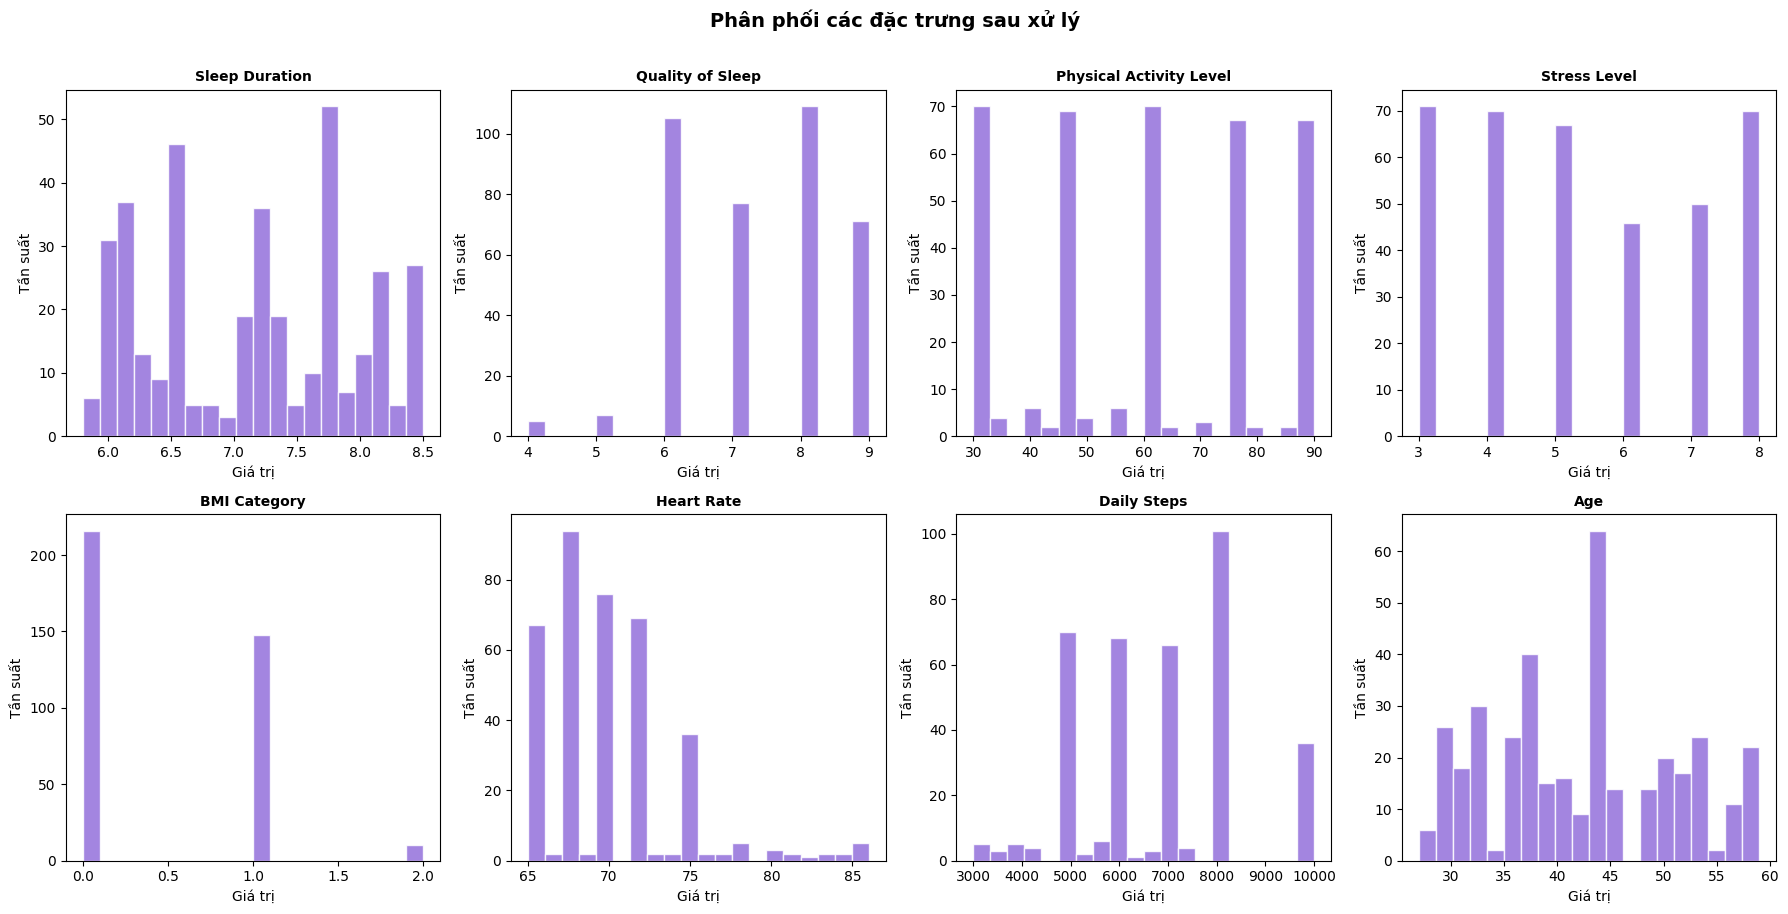

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

cols_to_plot = ['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
                'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Age']

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df_work[col], bins=20, color='mediumpurple', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Giá trị')
    ax.set_ylabel('Tần suất')

plt.suptitle('Phân phối các đặc trưng sau xử lý', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

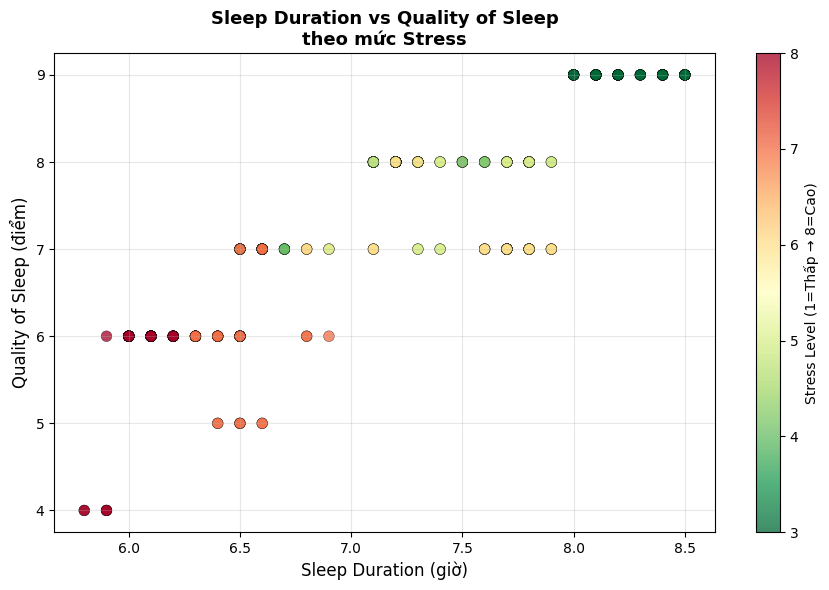

In [8]:
# Scatter: Sleep Duration vs Quality of Sleep theo Stress Level
plt.figure(figsize=(9, 6))
sc = plt.scatter(df_work['Sleep Duration'], df_work['Quality of Sleep'],
                 c=df_work['Stress Level'], cmap='RdYlGn_r', alpha=0.75, s=60, edgecolors='k', linewidths=0.3)
plt.colorbar(sc, label='Stress Level (1=Thấp → 8=Cao)')
plt.xlabel('Sleep Duration (giờ)', fontsize=12)
plt.ylabel('Quality of Sleep (điểm)', fontsize=12)
plt.title('Sleep Duration vs Quality of Sleep\ntheo mức Stress', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

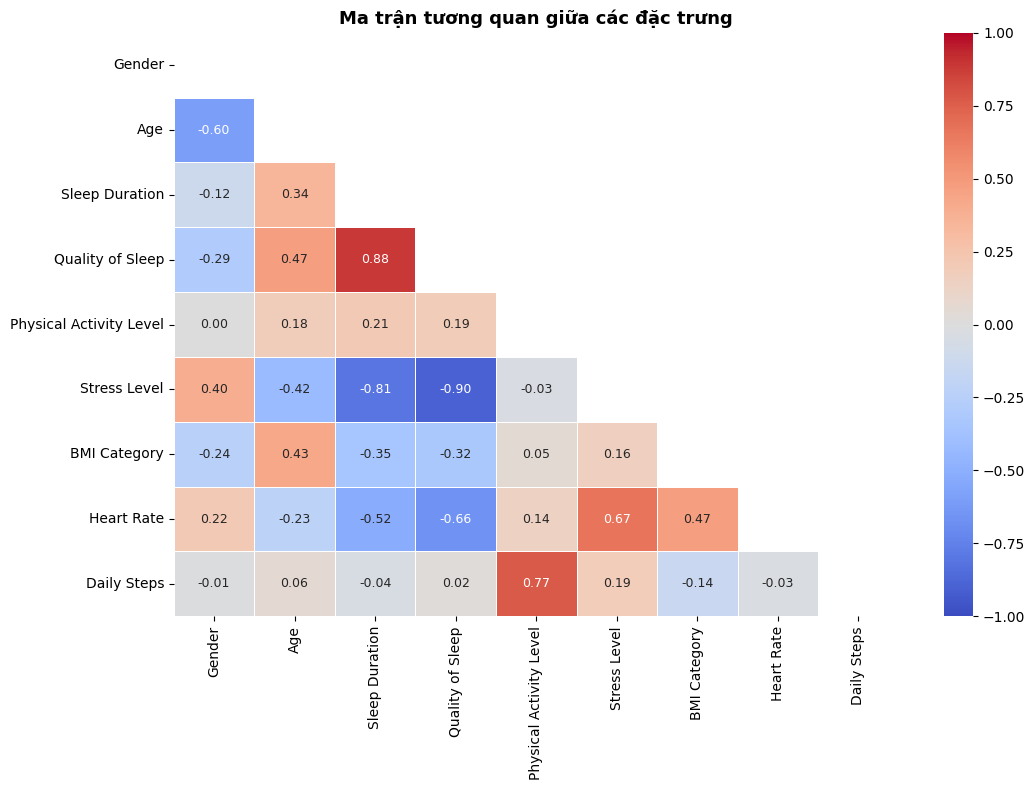

In [9]:
# Heatmap tương quan
plt.figure(figsize=(11, 8))
corr = df_work.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Ma trận tương quan giữa các đặc trưng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_354/1827326571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BMI Label', y='Quality of Sleep', data=df_plot,


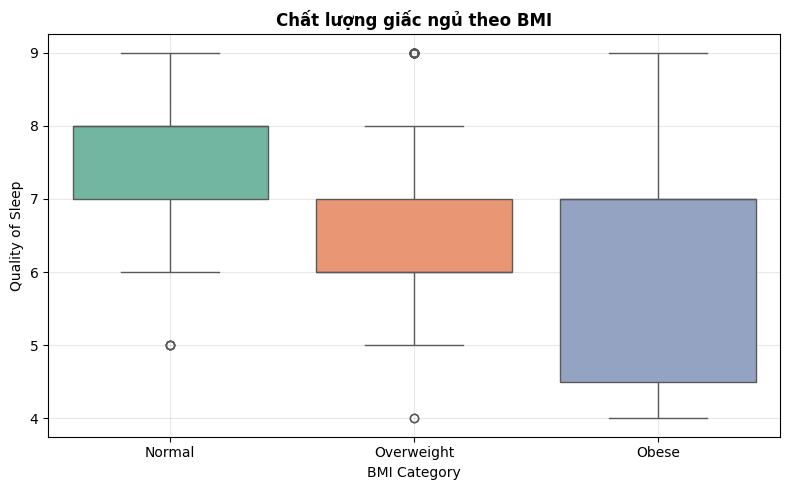

In [10]:
# Boxplot Quality of Sleep theo BMI Category
bmi_labels = {0: 'Normal', 1: 'Overweight', 2: 'Obese'}
df_plot = df_work.copy()
df_plot['BMI Label'] = df_plot['BMI Category'].map(bmi_labels)

plt.figure(figsize=(8, 5))
sns.boxplot(x='BMI Label', y='Quality of Sleep', data=df_plot,
            palette='Set2', order=['Normal', 'Overweight', 'Obese'])
plt.title('Chất lượng giấc ngủ theo BMI', fontsize=12, fontweight='bold')
plt.xlabel('BMI Category'); plt.ylabel('Quality of Sleep')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ⚙️ Bước 6: Chuẩn hóa & Tìm số cụm K tối ưu

In [11]:
# Chọn đặc trưng để phân cụm (loại trừ Quality of Sleep - dùng để đánh giá sau)
features = ['Sleep Duration', 'Physical Activity Level', 'Stress Level',
            'BMI Category', 'Heart Rate', 'Daily Steps', 'Age', 'Gender']

X = df_work[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape dữ liệu phân cụm: {X_scaled.shape}")
print(f"Đặc trưng sử dụng: {features}")

Shape dữ liệu phân cụm: (374, 8)
Đặc trưng sử dụng: ['Sleep Duration', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Age', 'Gender']


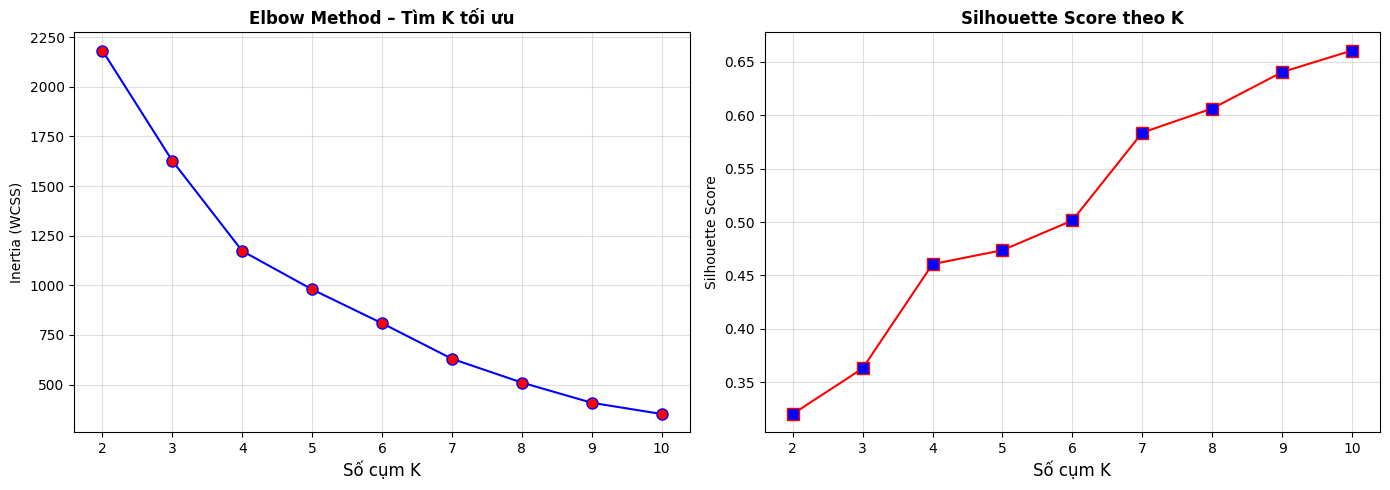


✅ K tối ưu: 10  (Silhouette = 0.6607)


In [12]:
# Tìm K tối ưu bằng Elbow + Silhouette
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inertias, 'bo-', markersize=8, markerfacecolor='red')
ax1.set_xlabel('Số cụm K', fontsize=12); ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method – Tìm K tối ưu', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.4)

ax2.plot(list(K_range), sil_scores, 'rs-', markersize=8, markerfacecolor='blue')
ax2.set_xlabel('Số cụm K', fontsize=12); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score theo K', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\n✅ K tối ưu: {best_k}  (Silhouette = {max(sil_scores):.4f})")

## 🤖 Bước 7a: K-Means dùng thư viện Sklearn

In [13]:
km_sklearn = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_sklearn.fit(X_scaled)
labels_sk = km_sklearn.labels_
sil_sk    = silhouette_score(X_scaled, labels_sk)

print(f"[Sklearn K-Means]")
print(f"  Silhouette Score : {sil_sk:.4f}")
print(f"  Inertia          : {km_sklearn.inertia_:.2f}")
print(f"  Số mẫu mỗi cụm   : {dict(zip(*np.unique(labels_sk, return_counts=True)))}")

# Phân tích đặc trưng trung bình theo cụm
df_result = df_work.copy()
df_result['Cluster_Sklearn'] = labels_sk

print("\n=== Trung bình đặc trưng theo cụm (Sklearn) ===")
summary_sk = df_result.groupby('Cluster_Sklearn')[features + ['Quality of Sleep']].mean().round(2)
print(summary_sk.to_string())

[Sklearn K-Means]
  Silhouette Score : 0.6607
  Inertia          : 352.05
  Số mẫu mỗi cụm   : {np.int32(0): np.int64(102), np.int32(1): np.int64(20), np.int32(2): np.int64(27), np.int32(3): np.int64(31), np.int32(4): np.int64(32), np.int32(5): np.int64(35), np.int32(6): np.int64(41), np.int32(7): np.int64(32), np.int32(8): np.int64(44), np.int32(9): np.int64(10)}

=== Trung bình đặc trưng theo cụm (Sklearn) ===
                 Sleep Duration  Physical Activity Level  Stress Level  BMI Category  Heart Rate  Daily Steps    Age  Gender  Quality of Sleep
Cluster_Sklearn                                                                                                                               
0                          7.56                    74.33          5.34          0.01       69.50      7968.63  36.73    1.00              7.63
1                          6.49                    43.80          6.75          0.70       75.85      5240.00  41.00    0.00              6.05
2           

## 🛠️ Bước 7b: K-Means tự cài đặt (không dùng Sklearn)

In [14]:
class KMeansCustom:
    """
    Thuật toán K-Means cài đặt thủ công (không dùng sklearn).
    Sử dụng khoảng cách Euclidean và cập nhật centroid theo trung bình cụm.
    """
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.tol          = tol
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        # Khởi tạo: chọn ngẫu nhiên K điểm làm centroid ban đầu
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids_ = X[idx].copy()

        for iteration in range(self.max_iter):
            # Bước 1: Tính khoảng cách từ mỗi điểm đến từng centroid
            dists = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids_])

            # Bước 2: Gán mỗi điểm vào cụm có centroid gần nhất
            self.labels_ = np.argmin(dists, axis=0)

            # Bước 3: Cập nhật centroid = trung bình của các điểm trong cụm
            new_centroids = np.array([
                X[self.labels_ == k].mean(axis=0) if np.any(self.labels_ == k)
                else self.centroids_[k]
                for k in range(self.n_clusters)
            ])

            # Bước 4: Kiểm tra hội tụ
            shift = np.linalg.norm(new_centroids - self.centroids_)
            self.centroids_ = new_centroids

            if shift < self.tol:
                print(f"  ✅ Hội tụ sau {iteration + 1} vòng lặp (shift={shift:.6f})")
                break

        # Tính Inertia (WCSS)
        self.inertia_ = float(sum(
            np.sum((X[self.labels_ == k] - self.centroids_[k]) ** 2)
            for k in range(self.n_clusters)
        ))
        return self

    def predict(self, X):
        dists = np.array([np.linalg.norm(X - c, axis=1) for c in self.centroids_])
        return np.argmin(dists, axis=0)

# Huấn luyện
km_custom = KMeansCustom(n_clusters=best_k, random_state=42)
km_custom.fit(X_scaled)
labels_cu = km_custom.labels_
sil_cu    = silhouette_score(X_scaled, labels_cu)

print(f"\n[Custom K-Means]")
print(f"  Silhouette Score : {sil_cu:.4f}")
print(f"  Inertia          : {km_custom.inertia_:.2f}")
print(f"  Số mẫu mỗi cụm   : {dict(zip(*np.unique(labels_cu, return_counts=True)))}")

df_result['Cluster_Custom'] = labels_cu
print("\n=== Trung bình đặc trưng theo cụm (Custom) ===")
summary_cu = df_result.groupby('Cluster_Custom')[features + ['Quality of Sleep']].mean().round(2)
print(summary_cu.to_string())

  ✅ Hội tụ sau 12 vòng lặp (shift=0.000000)

[Custom K-Means]
  Silhouette Score : 0.4893
  Inertia          : 701.48
  Số mẫu mỗi cụm   : {np.int64(0): np.int64(12), np.int64(1): np.int64(10), np.int64(2): np.int64(8), np.int64(3): np.int64(20), np.int64(4): np.int64(16), np.int64(5): np.int64(72), np.int64(6): np.int64(27), np.int64(7): np.int64(68), np.int64(8): np.int64(35), np.int64(9): np.int64(106)}

=== Trung bình đặc trưng theo cụm (Custom) ===
                Sleep Duration  Physical Activity Level  Stress Level  BMI Category  Heart Rate  Daily Steps    Age  Gender  Quality of Sleep
Cluster_Custom                                                                                                                               
0                         8.39                    30.00          3.00          0.00       65.00      5000.00  51.83    0.00              9.00
1                         6.96                    55.00          5.70          2.00       84.30      3350.00  38.00 

## 📈 Bước 8: So sánh Sklearn vs Custom K-Means

TIÊU CHÍ                          SKLEARN     CUSTOM
Silhouette Score                   0.6607     0.4893
Inertia (WCSS)                     352.05     701.48
Số cụm K                               10         10

Adjusted Rand Index (ARI): 0.7474
(ARI = 1.0 → hai phương pháp cho kết quả hoàn toàn giống nhau)


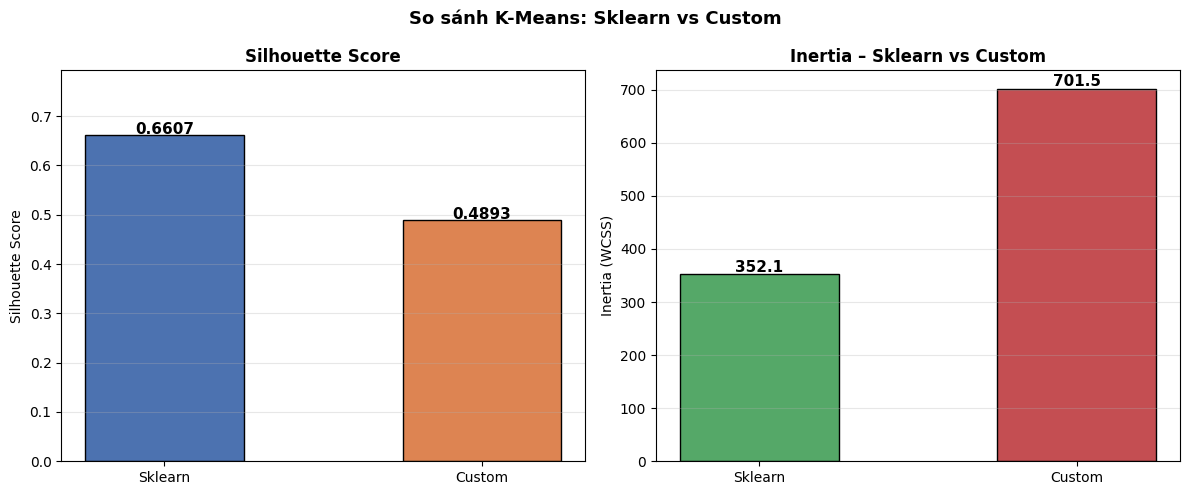

In [15]:
ari = adjusted_rand_score(labels_sk, labels_cu)

print("=" * 55)
print(f"{'TIÊU CHÍ':<30} {'SKLEARN':>10} {'CUSTOM':>10}")
print("=" * 55)
print(f"{'Silhouette Score':<30} {sil_sk:>10.4f} {sil_cu:>10.4f}")
print(f"{'Inertia (WCSS)':<30} {km_sklearn.inertia_:>10.2f} {km_custom.inertia_:>10.2f}")
print(f"{'Số cụm K':<30} {best_k:>10} {best_k:>10}")
print("=" * 55)
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print("(ARI = 1.0 → hai phương pháp cho kết quả hoàn toàn giống nhau)")

# Biểu đồ so sánh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Silhouette
bars1 = ax1.bar(['Sklearn', 'Custom'], [sil_sk, sil_cu],
                color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
for bar, v in zip(bars1, [sil_sk, sil_cu]):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.003,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
ax1.set_ylabel('Silhouette Score'); ax1.set_ylim(0, max(sil_sk, sil_cu)*1.2)
ax1.set_title('Silhouette Score', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Inertia
bars2 = ax2.bar(['Sklearn', 'Custom'], [km_sklearn.inertia_, km_custom.inertia_],
                color=['#55A868', '#C44E52'], edgecolor='black', width=0.5)
for bar, v in zip(bars2, [km_sklearn.inertia_, km_custom.inertia_]):
    ax2.text(bar.get_x()+bar.get_width()/2, v+5,
             f'{v:.1f}', ha='center', fontweight='bold', fontsize=11)
ax2.set_ylabel('Inertia (WCSS)')
ax2.set_title('Inertia – Sklearn vs Custom', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('So sánh K-Means: Sklearn vs Custom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🗺️ Bước 9: Trực quan hóa cụm (PCA 2D)

Tỷ lệ phương sai giải thích: PC1=35.2%, PC2=23.3%
Tổng: 58.5%


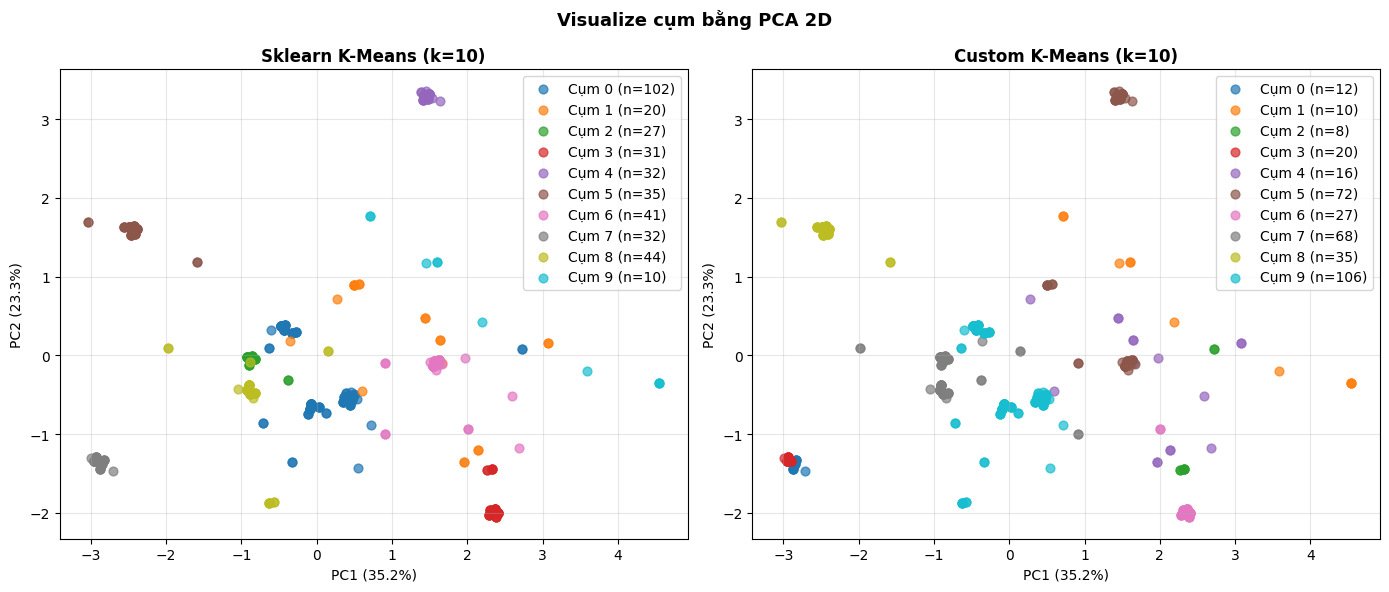

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"Tỷ lệ phương sai giải thích: PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}%")
print(f"Tổng: {sum(explained)*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for k in range(best_k):
    mask = labels_sk == k
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cụm {k} (n={mask.sum()})', alpha=0.7, s=40, color=colors[k])
ax1.set_title(f'Sklearn K-Means (k={best_k})', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax1.legend(); ax1.grid(True, alpha=0.3)

for k in range(best_k):
    mask = labels_cu == k
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cụm {k} (n={mask.sum()})', alpha=0.7, s=40, color=colors[k])
ax2.set_title(f'Custom K-Means (k={best_k})', fontsize=12, fontweight='bold')
ax2.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Visualize cụm bằng PCA 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

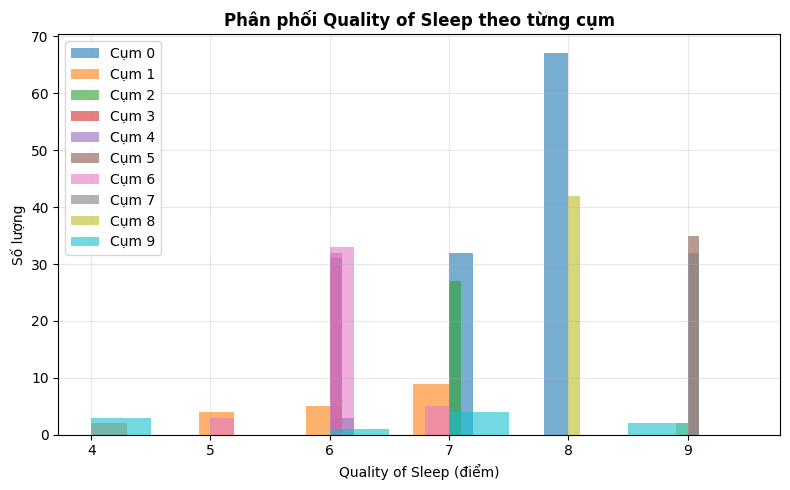


=== Quality of Sleep trung bình theo cụm ===
                 Trung bình  Min  Max  Số mẫu
Cluster_Sklearn                              
0                      7.63    6    8     102
1                      6.05    4    7      20
2                      7.00    7    7      27
3                      6.00    6    6      31
4                      6.00    6    6      32
5                      9.00    9    9      35
6                      6.05    5    7      41
7                      9.00    9    9      32
8                      8.05    8    9      44
9                      6.40    4    9      10


In [17]:
# Phân tích Quality of Sleep theo từng cụm (Sklearn)
plt.figure(figsize=(8, 5))
for k in range(best_k):
    cluster_quality = df_result[df_result['Cluster_Sklearn'] == k]['Quality of Sleep']
    plt.hist(cluster_quality, bins=10, alpha=0.6, label=f'Cụm {k}')
plt.xlabel('Quality of Sleep (điểm)')
plt.ylabel('Số lượng')
plt.title('Phân phối Quality of Sleep theo từng cụm', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In thống kê Quality of Sleep theo cụm
print("\n=== Quality of Sleep trung bình theo cụm ===")
qs_stats = df_result.groupby('Cluster_Sklearn')['Quality of Sleep'].agg(['mean','min','max','count']).round(2)
qs_stats.columns = ['Trung bình', 'Min', 'Max', 'Số mẫu']
print(qs_stats.to_string())

## 🖥️ Bước 10: Giao diện nhập liệu dự đoán cụm

In [ ]:
# Precompute cluster quality info for display
cluster_info = df_result.groupby('Cluster_Sklearn')['Quality of Sleep'].mean()

# Widgets
sleep_dur_w = widgets.FloatText(value=7.0, step=0.5, description='Sleep Dur (h):',
                                 style={'description_width': '140px'}, layout=widgets.Layout(width='300px'))
physical_w  = widgets.IntSlider(value=50, min=0, max=120, description='Physical Act:',
                                 style={'description_width': '140px'}, layout=widgets.Layout(width='350px'))
stress_w    = widgets.IntSlider(value=5, min=1, max=8, description='Stress Level:',
                                 style={'description_width': '140px'}, layout=widgets.Layout(width='350px'))
bmi_w       = widgets.Dropdown(options=[('Normal', 0), ('Overweight', 1), ('Obese', 2)],
                                value=0, description='BMI Category:',
                                style={'description_width': '140px'}, layout=widgets.Layout(width='300px'))
heart_w     = widgets.IntText(value=70, description='Heart Rate:',
                               style={'description_width': '140px'}, layout=widgets.Layout(width='300px'))
steps_w     = widgets.IntText(value=7000, description='Daily Steps:',
                               style={'description_width': '140px'}, layout=widgets.Layout(width='300px'))
age_w       = widgets.IntText(value=30, description='Age:',
                               style={'description_width': '140px'}, layout=widgets.Layout(width='300px'))
gender_w    = widgets.Dropdown(options=[('Male', 1), ('Female', 0)], value=1,
                                description='Gender:',
                                style={'description_width': '140px'}, layout=widgets.Layout(width='300px'))

btn = widgets.Button(description='🔍 Dự đoán Cụm', button_style='primary',
                     layout=widgets.Layout(width='200px', height='40px'))
out = widgets.Output()

def on_predict(b):
    with out:
        clear_output()
        vals = np.array([[
            sleep_dur_w.value, physical_w.value, stress_w.value,
            bmi_w.value, heart_w.value, steps_w.value,
            age_w.value, gender_w.value
        ]])
        scaled = scaler.transform(vals)
        c_sk = km_sklearn.predict(scaled)[0]
        c_cu = km_custom.predict(scaled)[0]
        qs_mean = cluster_info[c_sk]

        print("━" * 40)
        print(f"  ✅ Sklearn  → Cụm {c_sk}")
        print(f"  ✅ Custom   → Cụm {c_cu}")
        print(f"\n  📊 Sleep Quality TB của Cụm {c_sk}: {qs_mean:.2f} / 10")
        if qs_mean >= 7.5:
            print("  💤 Giấc ngủ: RẤT TỐT 🟢")
        elif qs_mean >= 6:
            print("  😊 Giấc ngủ: TỐT 🟡")
        elif qs_mean >= 4.5:
            print("  😐 Giấc ngủ: TRUNG BÌNH 🟠")
        else:
            print("  😴 Giấc ngủ: KÉM – cần cải thiện! 🔴")
        print("━" * 40)

btn.on_click(on_predict)

display(widgets.VBox([
    widgets.HTML("<h3 style='color:#6B2FA0'>🔍 Nhập thông tin để dự đoán cụm giấc ngủ</h3>"),
    widgets.HBox([sleep_dur_w, age_w]),
    widgets.HBox([physical_w, stress_w]),
    widgets.HBox([heart_w, steps_w]),
    widgets.HBox([bmi_w, gender_w]),
    widgets.HTML("<br>"),
    btn,
    out
]))